# Motor limit-region event — commanded vs stall

File: `metadata_20260627_173152.h5`. Azimuth only.

Step 5: zoom the parked region (t ≳ 260 s) where the motor counter swings ~90°
while the antenna (pot ≈ imu) sits still. Overlay `az_pos` vs `az_target_pos`
(raw steps) to decide:

- **commanded over-travel** → `az_target_pos` moves and `az_pos` follows it
  (the scan asked for the move; antenna stalled against the stop).
- **stall / false count** → `az_target_pos` holds but `az_pos` runs away
  (counter drifts with no command).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from eigsep_observing.io import read_metadata_hdf5

FNAME = "metadata_20260627_173152.h5"
here = Path.cwd()
data_path = next(
    (p / FNAME for p in [here, *here.parents] if (p / FNAME).exists()), None
)
assert data_path is not None
meta = read_metadata_hdf5(data_path)
STREAMS = ["motor", "potmon", "imu_az"]
T0 = min(s["_ts_unix"] for k in STREAMS for s in meta[k] if s is not None)


def series(stream, field, drop_error=True):
    rows = []
    for s in meta[stream]:
        if s is None or (drop_error and s.get("status") == "error"):
            continue
        val = s.get(field)
        if val is None:
            continue
        rows.append((s["_ts_unix"] - T0, val))
    rows.sort(key=lambda r: r[0])
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows])


t_pos, az_pos = series("motor", "az_pos")
t_tgt, az_tgt = series("motor", "az_target_pos")
t_i, yaw = series("imu_az", "yaw")
imu_deg = np.unwrap(yaw, period=360.0)
t_p, volts = series("potmon", "pot_az_voltage")
# pot -> deg via imu fit (for the truth panel only)
c, d = np.polyfit(np.interp(t_i, t_p, volts), imu_deg, 1)
pot_deg = c * volts + d

In [2]:
# Quantify the event in the zoom window.
W = 255.0


def win(t, y):
    m = t >= W
    return t[m], y[m]


_, pos_w = win(t_pos, az_pos)
_, tgt_w = win(t_tgt, az_tgt)
_, pot_w = win(t_p, pot_deg)
_, imu_w = win(t_i, imu_deg)
print(f"window t >= {W:.0f} s")
print(
    f"az_target_pos : {tgt_w.min():+8.0f} .. {tgt_w.max():+8.0f} steps  (span {np.ptp(tgt_w):.0f})"
)
print(
    f"az_pos        : {pos_w.min():+8.0f} .. {pos_w.max():+8.0f} steps  (span {np.ptp(pos_w):.0f})"
)
print(
    f"pot azimuth   : {pot_w.min():+8.1f} .. {pot_w.max():+8.1f} deg    (span {np.ptp(pot_w):.1f})"
)
print(
    f"imu azimuth   : {imu_w.min():+8.1f} .. {imu_w.max():+8.1f} deg    (span {np.ptp(imu_w):.1f})"
)
# does az_pos reach az_target (move completed) or fall short (stalled)?
tgt_final = az_tgt[-1]
pos_final = az_pos[-1]
print(
    f"\nfinal az_target={tgt_final:+.0f}  final az_pos={pos_final:+.0f}  "
    f"gap={pos_final - tgt_final:+.0f} steps"
)

window t >= 255 s
az_target_pos :    -8475 ..       +0 steps  (span 8475)
az_pos        :   -10720 ..       +0 steps  (span 10720)
pot azimuth   :    +53.3 ..   +121.0 deg    (span 67.7)
imu azimuth   :    +58.7 ..   +116.5 deg    (span 57.8)

final az_target=-5650  final az_pos=-7095  gap=-1445 steps


saved /home/christian/Documents/research/eigsep/eigsep_observing/notebooks/motor_pot_imu/05_limit_event.png


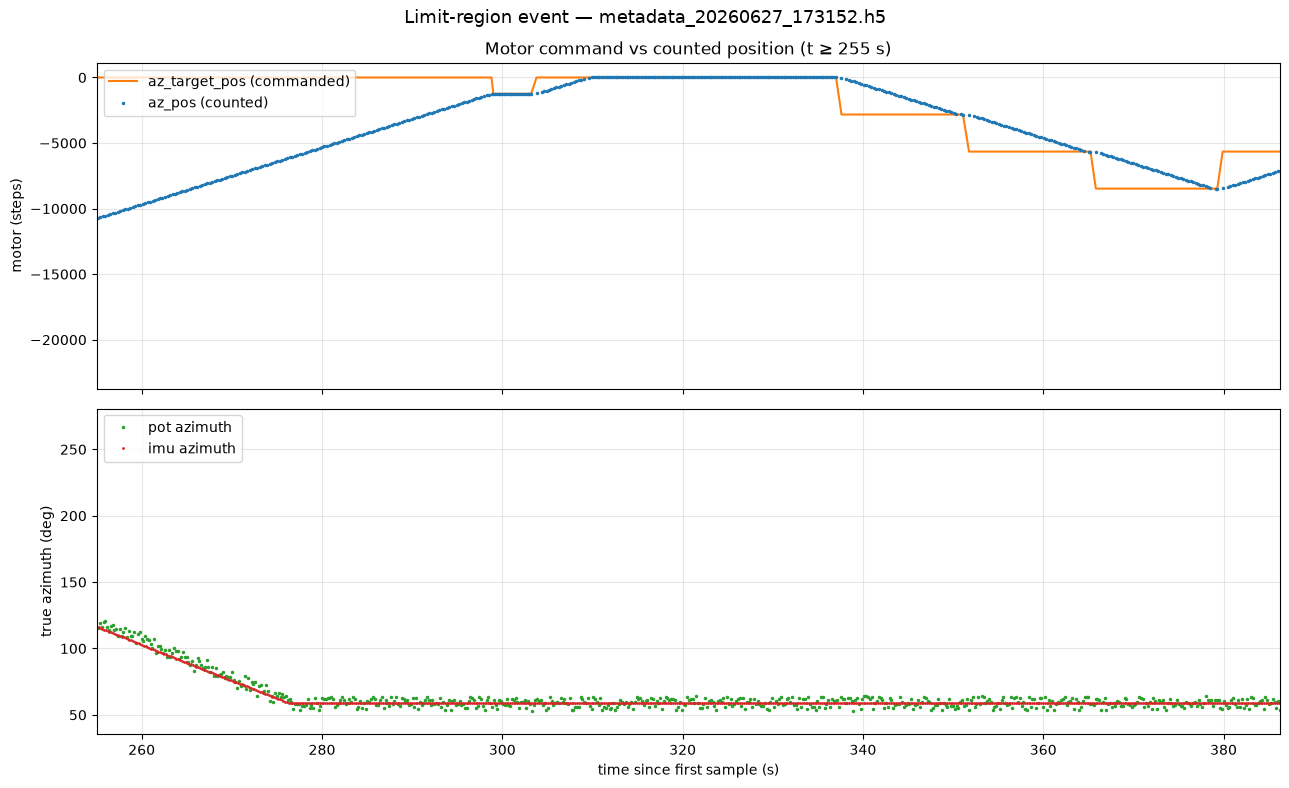

In [3]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# --- motor command vs position (raw steps) ---
ax0.plot(
    t_tgt,
    az_tgt,
    "-",
    lw=1.5,
    color="tab:orange",
    label="az_target_pos (commanded)",
)
ax0.plot(t_pos, az_pos, ".", ms=3, color="tab:blue", label="az_pos (counted)")
ax0.set_ylabel("motor (steps)")
ax0.set_xlim(W, max(t_pos.max(), t_tgt.max()))
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
ax0.set_title(f"Motor command vs counted position (t ≥ {W:.0f} s)")

# --- true azimuth (antenna actually moved?) ---
ax1.plot(t_p, pot_deg, ".", ms=3, color="tab:green", label="pot azimuth")
ax1.plot(t_i, imu_deg, ".", ms=2, color="tab:red", label="imu azimuth")
ax1.set_ylabel("true azimuth (deg)")
ax1.set_xlabel("time since first sample (s)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

fig.suptitle("Limit-region event — metadata_20260627_173152.h5", fontsize=13)
fig.tight_layout()
out = Path.cwd() / "05_limit_event.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)